In [3]:
import random
import string
import timeit

# Implementation

In [4]:
def rabin_karp(text, pattern, d=256, q=101):
    """
    Rabin-Karp algorithm for pattern searching.
    
    Args:
        text: The text to search in
        pattern: The pattern to search for
        d: Number of characters in the input alphabet (default 256 for ASCII)
        q: A prime number for hashing (default 101)
    
    Returns:
        List of starting indices where pattern is found in text
    """
    n = len(text)
    m = len(pattern)
    matches = []
    
    if m > n:
        return matches
    
    # Calculate hash value for pattern and first window of text
    p = 0  # hash value for pattern
    t = 0  # hash value for text window
    h = 1  # d^(m-1) % q
    
    # Calculate h = d^(m-1) % q
    for i in range(m - 1):
        h = (h * d) % q
    
    # Calculate initial hash values
    for i in range(m):
        p = (d * p + ord(pattern[i])) % q
        t = (d * t + ord(text[i])) % q
    
    # Slide the pattern over text
    for i in range(n - m + 1):
        # Check if hash values match
        if p == t:
            # If hash matches, check character by character
            if text[i:i + m] == pattern:
                matches.append(i)
        
        # Calculate hash for next window (if not last iteration)
        if i < n - m:
            # Remove leading character and add trailing character
            t = (d * (t - ord(text[i]) * h) + ord(text[i + m])) % q
            
            # Handle negative hash values
            if t < 0:
                t += q
    
    return matches

In [5]:
if __name__ == "__main__":
    text = "AABAACAADAABAABA"
    pattern = "AABA"
    
    print(f"Text: {text}")
    print(f"Pattern: {pattern}")
    
    result = rabin_karp(text, pattern)
    
    if result:
        print(f"\nPattern found at indices: {result}")
        for idx in result:
            print(f"  Index {idx}: {text[idx:idx + len(pattern)]}")
    else:
        print("\nPattern not found in text")
    
    print("\n" + "="*50)
    print("Additional test cases:")
    
    test_cases = [
        ("hello world hello", "hello"),
        ("abcdefg", "xyz"),
        ("ababcababa", "aba"),
        ("AAAA", "AA")
    ]
    
    for txt, pat in test_cases:
        result = rabin_karp(txt, pat)
        print(f"\nText: '{txt}'\nPattern: '{pat}'\nMatches at: {result}")

Text: AABAACAADAABAABA
Pattern: AABA

Pattern found at indices: [0, 9, 12]
  Index 0: AABA
  Index 9: AABA
  Index 12: AABA

Additional test cases:

Text: 'hello world hello'
Pattern: 'hello'
Matches at: [0, 12]

Text: 'abcdefg'
Pattern: 'xyz'
Matches at: []

Text: 'ababcababa'
Pattern: 'aba'
Matches at: [0, 5, 7]

Text: 'AAAA'
Pattern: 'AA'
Matches at: [0, 1, 2]


## Benchmarking

In [26]:
import random
import string
import time
import matplotlib.pyplot as plt

def generate_random_text(length):
    """
    Generates random text of specified length using lowercase letters.
    """
    return ''.join(random.choices(string.ascii_lowercase, k=length))

def generate_random_pattern(length):
    """
    Generates a random pattern of specified length.
    """
    return ''.join(random.choices(string.ascii_lowercase, k=length))

def benchmark_rabin_karp(text, pattern):
    """
    Benchmarks the Rabin-Karp algorithm.
    
    Args:
        text: The text to search in
        pattern: The pattern to search for
    
    Returns:
        Elapsed time in seconds
    """
    start_time = time.perf_counter()
    rabin_karp(text, pattern)
    end_time = time.perf_counter()
    elapsed = end_time - start_time
    
    return elapsed

Benchmark 1: Varying Text Length (Pattern length: 10)
Text length 100: 0.000028s
Text length 500: 0.000101s
Text length 1000: 0.000203s
Text length 2000: 0.000427s
Text length 3000: 0.000610s
Text length 5000: 0.001322s
Text length 7500: 0.002123s
Text length 10000: 0.002391s
Text length 15000: 0.003032s
Text length 20000: 0.004999s


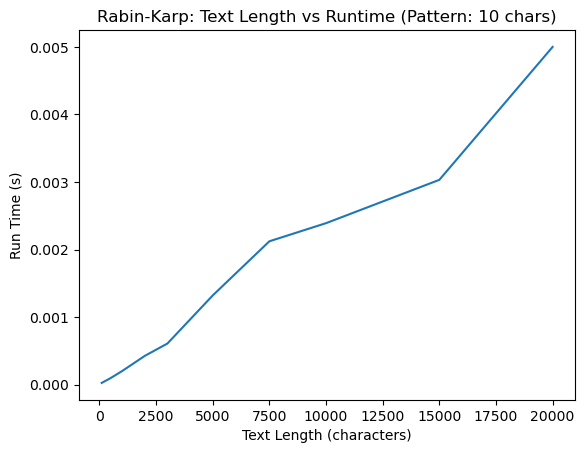

In [29]:
# Benchmark 1: Varying text length with fixed pattern length
print("Benchmark 1: Varying Text Length (Pattern length: 10)")
text_lengths = [100, 500, 1000, 2000, 3000, 5000, 7500, 10000, 15000, 20000]
pattern_length = 10
times_varying_text = []

for text_len in text_lengths:
    text = generate_random_text(text_len)
    pattern = generate_random_pattern(pattern_length)
    
    elapsed_time = benchmark_rabin_karp(text, pattern)
    times_varying_text.append(elapsed_time)
    print(f"Text length {text_len}: {elapsed_time:.6f}s")

# Plot
plt.plot(text_lengths, times_varying_text)
plt.xlabel("Text Length (characters)")
plt.ylabel("Run Time (s)")
plt.title("Rabin-Karp: Text Length vs Runtime (Pattern: 10 chars)")
plt.show()


Benchmark: Worst Case
Text 100,000 - Best: 0.034274s, Worst: 0.049235s
Text 500,000 - Best: 0.192816s, Worst: 0.216787s
Text 1,000,000 - Best: 0.390967s, Worst: 0.453358s
Text 2,000,000 - Best: 0.730467s, Worst: 0.809957s
Text 3,000,000 - Best: 1.043259s, Worst: 1.181839s
Text 5,000,000 - Best: 1.752220s, Worst: 2.101981s


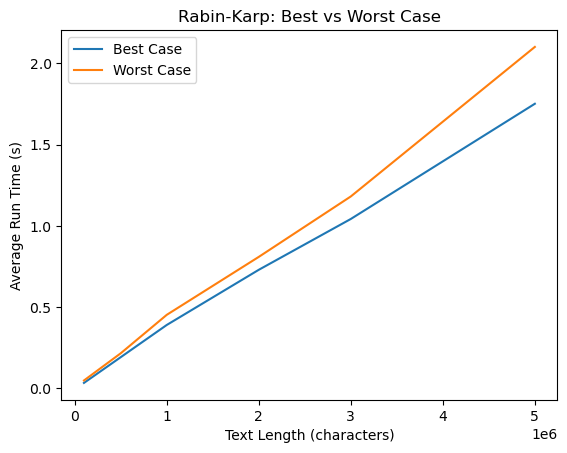

In [30]:
# Benchmark 2: Best Case vs Worst Case
print("\nBenchmark: Worst Case")
text_lengths = [10_0000, 50_0000, 100_0000, 200_0000, 300_0000, 500_0000]
pattern_length = 100
num_runs = 10

times_best_case = []
times_worst_case = []

for text_len in text_lengths:
    # Best case: no hash matches at all
    text_best = "a" * text_len
    pattern_best = "b" * pattern_length
    
    # Worst case: all hash matches
    text_worst = "a" * text_len
    pattern_worst = "a" * pattern_length  # Will match at EVERY position!
    
    # Best case
    best_times = []
    for _ in range(num_runs):
        elapsed = benchmark_rabin_karp(text_best, pattern_best)
        best_times.append(elapsed)
    times_best_case.append(sum(best_times) / len(best_times))
    
    # Worst case
    worst_times = []
    for _ in range(num_runs):
        elapsed = benchmark_rabin_karp(text_worst, pattern_worst)
        worst_times.append(elapsed)
    times_worst_case.append(sum(worst_times) / len(worst_times))
    
    print(f"Text {text_len:,} - Best: {times_best_case[-1]:.6f}s, Worst: {times_worst_case[-1]:.6f}s")

plt.plot(text_lengths, times_best_case, label = "Best Case")
plt.plot(text_lengths, times_worst_case, label = "Worst Case")
plt.xlabel("Text Length (characters)")
plt.ylabel("Average Run Time (s)")
plt.title("Rabin-Karp: Best vs Worst Case")
plt.legend()
plt.show()